# Semantic Segmentation

The main goal of this project is to tackle a problem of semantic segmentation, specifically the segmentation of road cracks.

Some code is already provided (mainly the data loading code). You can modify most of the code unless specifically stated that some section should not be changed.

In [ ]:
!pip install torchgeometry

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 2.0 MB/s eta 0:00:00


In [ ]:
# imports
from matplotlib import pyplot as plt
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import shutil
import random
random.seed(42) # DO NOT CHANGE THIS

from torchvision import models
from torchvision import transforms
from torch import nn
import time
from tqdm import tqdm
import torchgeometry as tgm

## Loading the data

Let's start by loading the data. You can find the dataset [here](https://drive.google.com/file/d/13L-Xe5gZPEg3kNWh4sl0uxoVM4C4OlYL/view?usp=share_link).

Download the zip file and upload it to your google drive.

Let's now mount the drive and access the folder where you saved the dataset.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# access the data
datadir = '/content/drive/MyDrive/Colab Notebooks/AIPA/dataset.zip' # change this path to where you stored the dataset

# unzip dataset
shutil.unpack_archive(datadir)

In [ ]:
# DO NOT CHANGE THIS CELL
images_list = os.listdir('dataset/images')
random.shuffle(images_list)

train_list = images_list[:300]
val_list = images_list[300:350]
test_list = images_list[350:]

## Visualizing the data

In the following section, you can use the function ``` display_image_grid ``` to visualize the data.



In [ ]:
# note that you can use this function to visualize your model's predictions
def display_image_grid(images_filenames, images_directory='dataset', predicted_masks=None):
    cols = 3 if predicted_masks else 2
    rows = len(images_filenames)
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 24))
    for i, image_filename in enumerate(images_filenames):
        # read image and convert to RGB
        image = cv2.imread(os.path.join(images_directory, 'images', image_filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # read mask
        mask = cv2.imread(os.path.join(images_directory, 'masks', image_filename), cv2.IMREAD_GRAYSCALE)
        mask[mask <= 127] = 0
        mask[mask > 127] = 1

        # plot
        ax[i, 0].imshow(image)
        ax[i, 1].imshow(mask, cmap='gray')

        ax[i, 0].set_title("Image")
        ax[i, 1].set_title("Ground truth mask")

        ax[i, 0].set_axis_off()
        ax[i, 1].set_axis_off()

        if predicted_masks:
            predicted_mask = predicted_masks[0]
            ax[i, 2].imshow(predicted_mask, cmap='gray')
            ax[i, 2].set_title("Predicted mask")
            ax[i, 2].set_axis_off()
    plt.tight_layout()
    plt.show()

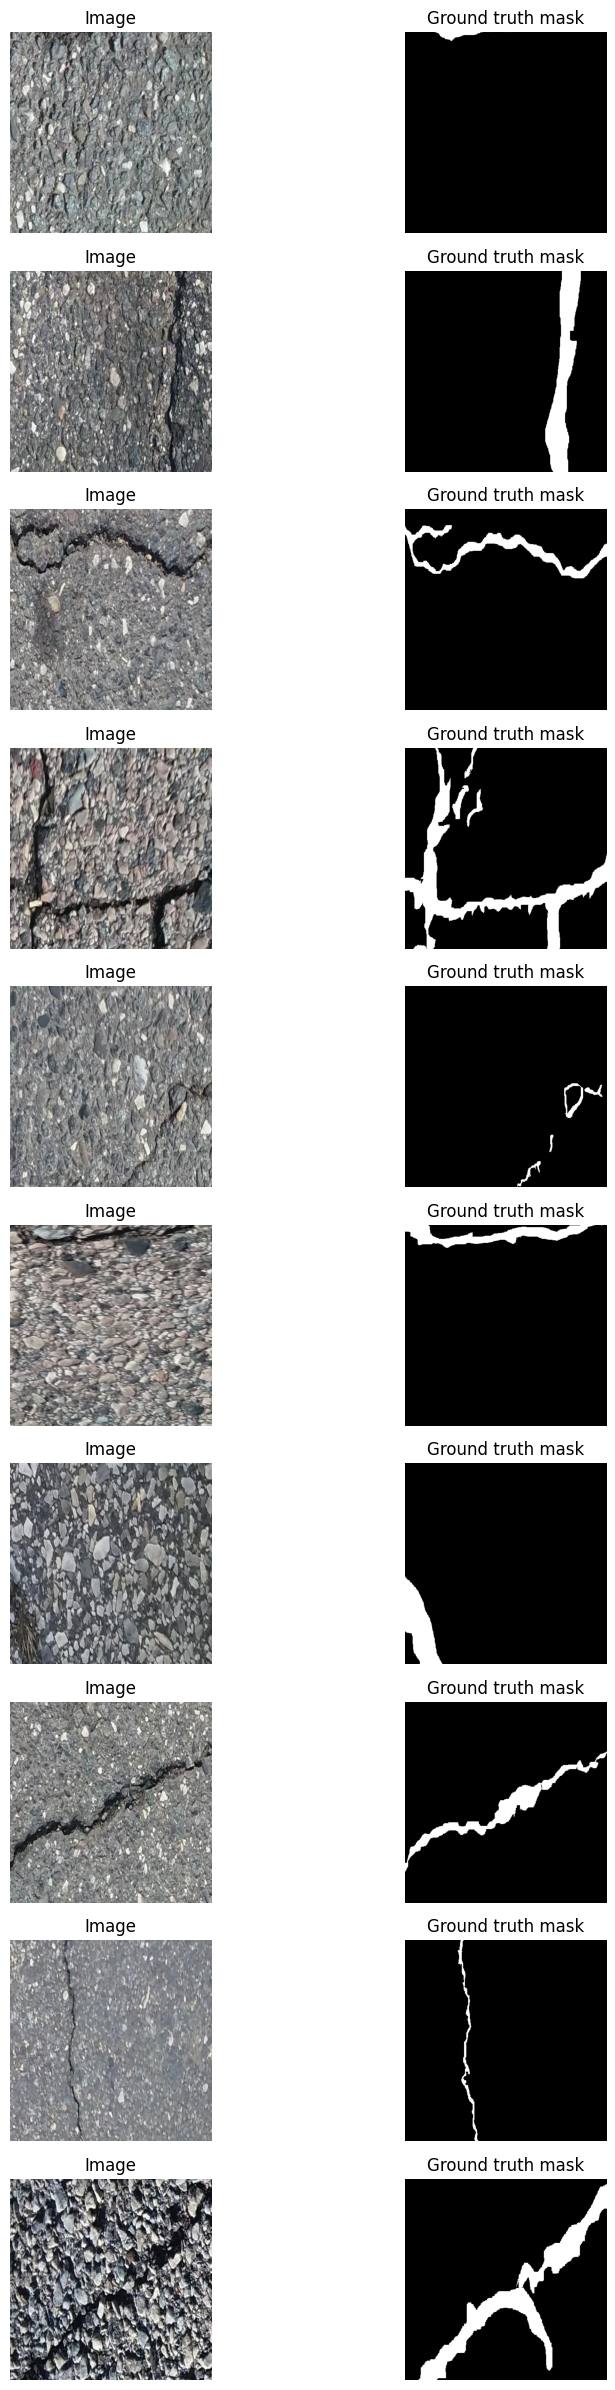

In [ ]:
display_image_grid(train_list[:10], 'dataset')

## Building the Dataset

In [ ]:
class RoadCracksDataset(Dataset):
    def __init__(self, images_list, images_directory='dataset', transform=None):
        self.images_list = images_list
        self.images_directory = images_directory
        self.transform = transform

    def __len__(self):
        return len(self.images_list)

    def __getitem__(self, idx):
        image_filename = self.images_list[idx]
        image = cv2.imread(os.path.join(self.images_directory, 'images', image_filename))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(os.path.join(self.images_directory, 'masks', image_filename), cv2.IMREAD_GRAYSCALE)
        mask[mask <= 127] = 0
        mask[mask > 127] = 1
       
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        return image, mask.to(torch.int64)

In [ ]:
# define transforms
transform = A.Compose(
    [
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        A.Resize(img_height, img_width),
        ToTensorV2()
    ]
)
# feel free to add data augmentation if you see fit 

In [ ]:
# build the dataset and dataloaders
# DO NOT CHANGE THIS CELL (particularly the shuffling)
train_dataset = RoadCracksDataset(train_list, transform=transform)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)

val_dataset = RoadCracksDataset(val_list, transform=transform)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

test_dataset = RoadCracksDataset(test_list, transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

## Defining the hyperparameters and functions


In [ ]:
# hyperparameters
nr_classes = 2 # this is a binary segmentation problem
batch_size = 64
num_workers = 2
epochs = 15
nr_channels = 1
learning_rate = 1e-4
img_height = 100
img_width = 100

# device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
# IoU function
SMOOTH = 1e-6

def iou_pytorch(outputs: torch.Tensor, labels: torch.Tensor):
    
    intersection = torch.logical_and(outputs, labels).float().sum((1, 2))  # Will be zero if Truth=0 or Prediction=0
    union = torch.logical_or(outputs, labels).float().sum((1, 2))         # Will be zzero if both are 0
    
    # Smooth the division to avoid 0/0
    iou = (intersection + SMOOTH) / (union + SMOOTH)  
    
    thresholded = torch.clamp(20 * (iou - 0.4), 0, 10).ceil() / 10  # This is equal to comparing with thresolds
    # print(iou.mean(), thresholded.mean())
    return iou.mean(), thresholded.mean()  # Or thresholded.mean() if you are interested in average across the batch
  

# Accuracy function
def accuracy(outputs, mask):
    total = torch.numel(outputs)
    correct = (outputs == mask).sum().item()
    return correct/total

## Exercise 1

Finetune a pretrained segmentation model on the RoadCracks dataset using the standard cross entropy loss.

Measure the performance of your model **on the test set** in terms of:
*   pixel accuracy
*   Intersection over Union (IoU)

Plot some of the obtained segmentation results and compare them with the ground truth.




In [ ]:
# load pretrained model (do not forget to change the number of classes)
weights = models.segmentation.FCN_ResNet101_Weights.DEFAULT
model = models.segmentation.fcn_resnet101(weights=weights)

# print(model)

In [ ]:
# Recreate the classifier layer for our num of segments
model.classifier[4] = nn.Conv2d(512, nr_channels, kernel_size=(1, 1), stride=(1, 1))
model.aux_classifier[4] = nn.Conv2d(256, nr_channels, kernel_size=(1, 1), stride=(1, 1))


### Training the model

In [ ]:
# put model in GPU
model.to(device)

# initialize loss function and optimizer
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# calculate steps per epoch for training and test set
train_steps = len(train_dataloader)
test_steps = len(val_dataloader)

# initialize a dictionary to store training history
H = {"train_loss": [], "train_acc": [], "train_iou": [], "val_loss": [], "val_acc": [], "val_iou": []}


In [ ]:
# train the model
print("[INFO] training the network...")
startTime = time.time()

# loop over epochs
for e in range(epochs):
  
  # Setup train loss and train accuracy values
  train_loss = 0
  test_loss = 0
  train_acc = 0
  test_acc = 0
  train_iou = 0
  test_iou = 0
  train_iou_thr = 0
  test_iou_thr = 0

	# set the model in training mode
  model.train()

  # Loop through data loader data batches
  for batch, (X, y) in tqdm(enumerate(train_dataloader)):
    
    # Send data to target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)
    y_pred = y_pred['out']
    
    # 2. Calculate  and accumulate loss
    loss = loss_fn(torch.sigmoid(y_pred.squeeze()), y.to(torch.float32))
    train_loss += loss.item()

    pred = torch.sigmoid(y_pred.squeeze())
    pred[pred > 0.5] = 1
    pred[pred <= 0.5] = 0

    acc = accuracy(pred, y)
    train_acc += acc

    iou, iou_thrs = iou_pytorch(pred, y)
    train_iou += iou.item()
    train_iou_thr += iou_thrs.item()
    # print(loss, acc, iou.item(), iou_thrs.item())

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

	# switch off autograd
  with torch.no_grad():
		
    # set the model in evaluation mode
    model.eval()
		
    # loop over the validation set
    for (X, y) in val_dataloader:
			# Send data to target device
      X, y = X.to(device), y.to(device)

			# make the predictions
      y_pred = model(X)
      y_pred = y_pred['out']

      # calculate the validation loss and accuracy
      pred = torch.sigmoid(y_pred.squeeze())
      loss = loss_fn(pred, y.to(torch.float32))
      test_loss += loss.item()

      pred[pred > 0.5] = 1
      pred[pred <= 0.5] = 0

      acc = accuracy(pred, y)
      test_acc += acc

      iou, iou_thrs = iou_pytorch(pred, y)
      test_iou += iou.item()
      test_iou_thr += iou_thrs.item()
      # print(loss, acc, iou.item(), iou_thrs.item())
   
	# Adjust metrics to get average loss per batch 
  train_loss = train_loss / train_steps
  test_loss = test_loss / test_steps
  train_acc = train_acc / train_steps
  test_acc = test_acc / test_steps
  train_iou = train_iou / train_steps
  test_iou = test_iou / test_steps
  train_iou_thr = train_iou_thr / train_steps
  test_iou_thr = test_iou_thr / test_steps

	# update our training history
  H["train_loss"].append(train_loss)
  H["val_loss"].append(test_loss)
  H["train_acc"].append(train_acc)
  H["val_acc"].append(test_acc)
  H["train_iou"].append(train_iou)
  H["val_iou"].append(test_iou)
	
  # print the model training and validation information
  print("[INFO] EPOCH: {}/{}".format(e + 1, epochs))
  print("Train loss: {:.6f}, Train acc: {:.6f}, Train iou: {:.6f}, Train iou_thr: {:.6f}, Val loss: {:.4f}, Val acc: {:.4f}, Val iou: {:.4f}, Val iou_thr: {:.6f}"\
        .format(train_loss, train_acc,train_iou, train_iou_thr,
                test_loss, test_acc, test_iou, test_iou_thr))

# display the total time needed to perform the training
endTime = time.time()
print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))


[INFO] training the network...


5it [00:12,  2.55s/it]


[INFO] EPOCH: 1/15
Train loss: 0.636406, Train acc: 0.693576, Train iou: 0.122714, Train iou_thr: 0.004063, Val loss: 0.6925, Val acc: 0.5041, Val iou: 0.0953, Val iou_thr: 0.000000


5it [00:05,  1.07s/it]


[INFO] EPOCH: 2/15
Train loss: 0.517123, Train acc: 0.866967, Train iou: 0.223135, Train iou_thr: 0.015369, Val loss: 0.5503, Val acc: 0.9164, Val iou: 0.2176, Val iou_thr: 0.012000


...

[INFO] EPOCH: 13/15
Train loss: 0.265099, Train acc: 0.961157, Train iou: 0.419153, Train iou_thr: 0.224432, Val loss: 0.3122, Val acc: 0.9445, Val iou: 0.3243, Val iou_thr: 0.096000


5it [00:05,  1.14s/it]


[INFO] EPOCH: 14/15
Train loss: 0.261426, Train acc: 0.962682, Train iou: 0.418934, Train iou_thr: 0.228892, Val loss: 0.2766, Val acc: 0.9512, Val iou: 0.3397, Val iou_thr: 0.120000


5it [00:05,  1.13s/it]


[INFO] EPOCH: 15/15
Train loss: 0.248046, Train acc: 0.967034, Train iou: 0.434150, Train iou_thr: 0.264915, Val loss: 0.2779, Val acc: 0.9523, Val iou: 0.3234, Val iou_thr: 0.114000
[INFO] total time taken to train the model: 107.60s


### Testing the model

In [ ]:
num_correct = 0
num_pixels  = 0
iou_score  = 0
model.eval()

with torch.no_grad():
    for (X, y) in test_dataloader:
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # make the predictions
        y_pred = model(X)
        y_pred = y_pred['out']
        
        pred = torch.sigmoid(y_pred.squeeze())
        pred[pred > 0.5] = 1
        pred[pred <= 0.5] = 0

        num_correct += (pred == y).sum().item()
        num_pixels += torch.numel(pred)
        iou, _ = iou_pytorch(pred.squeeze(), y)
        iou_score += iou.item()

# print(f"Got {num_correct}/{num_pixels}")
print(f"Pixel accuracy: {num_correct/num_pixels:.2f}")
print(f"IoU score: {iou_score/len(test_dataloader):.2f}")

# Saving the model
torch.save(model.state_dict(), 'model_exec1.h5')

Pixel accuracy: 0.95
IoU score: 0.32


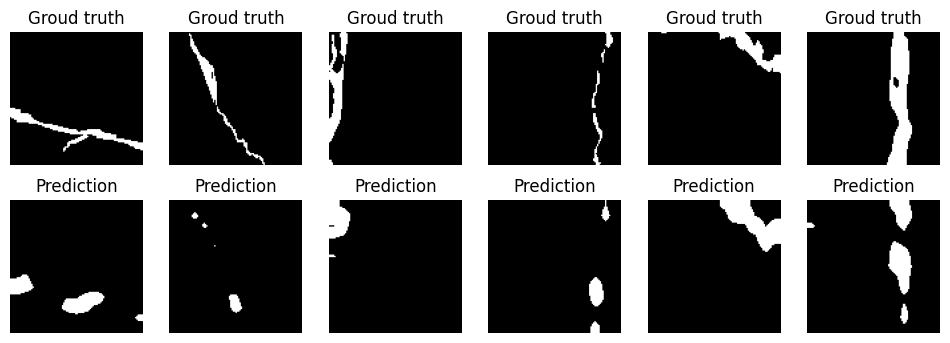

In [ ]:
# plot some examples of obtained segmentations
rows = 1
cols = 6

size_each = 2
fig, axes = plt.subplots(rows*2, cols,figsize =(cols*size_each, rows*2*size_each) )

for ax in axes.reshape(-1):
  ax.axis('off')

counter = random.randint(0, len(test_dataset) - cols*rows)
for r in range(rows):
  for c in range(cols):
    sample, mask = test_dataset[counter]
    counter += 1

        # do inference
    model.eval()
    with torch.no_grad():
      
      y_pred = model(sample.unsqueeze(0).to(device))
      y_pred = y_pred['out']

      pred = torch.sigmoid(y_pred.squeeze())
      pred[pred > 0.5] = 1
      pred[pred <= 0.5] = 0

    axes[r*2][c].imshow(mask, cmap='gray')
    axes[r*2][c].title.set_text('Groud truth')
    
    axes[r*2+1][c].imshow(pred.to('cpu'), cmap='gray')
    axes[r*2+1][c].title.set_text('Prediction')

How do both metrics (accuracy vs IoU) compare? Is one of them higher than the other? If so, why? Answer below.

Pixel accuracy counts the correct number of pixels predicted versus the total of pixels; while IoU divides the area of overlap between the bounding boxes by the area of union.

Looking at the results, the pixel accuracy metric (0.95) is quite higher than IoU score (0.32) because, in this case, the proportion of pixels in the background is significatively higher than in the foreground, so, when computing the number of correct pixels (background + foreground) versus the total number of pixels, by default, is going to be very high, even if the predictions for foreground are a few. However, IoU score is a better metric for segmentation problems because takes into account the object to be detected, in this case, the cracked from the road.

## Exercise 2

The dataset is clearly imbalanced, i.e. there are more background pixels than foreground pixels.

Is the cross entropy loss the best choice for this scenario?

Retrain your model using a loss that takes the class imbalance into account (e.g. Focal Loss). Take a look at the [PyTorch geometry](https://kornia.readthedocs.io/en/v0.1.2/losses.html) package for this purpose.

### Load pre-trained model and adapt it to our case

In [ ]:
# load pretrained model (do not forget to change the number of classes)
weights = models.segmentation.FCN_ResNet101_Weights.DEFAULT
model = models.segmentation.fcn_resnet101(weights=weights)

# Recreate the classifier layer for our num of segments
model.classifier[4] = nn.Conv2d(512, nr_classes, kernel_size=(1, 1), stride=(1, 1))
model.aux_classifier[4] = nn.Conv2d(256, nr_classes, kernel_size=(1, 1), stride=(1, 1))


### Training the model

In [ ]:
# put model in GPU
model.to(device)

# initialize loss function and optimizer
#loss_fn = tgm.losses.DiceLoss()
loss_fn = tgm.losses.DiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# calculate steps per epoch for training and test set
train_steps = len(train_dataloader)
test_steps = len(val_dataloader)

# initialize a dictionary to store training history
H = {"train_loss": [], "train_acc": [], "train_iou": [], "val_loss": [], "val_acc": [], "val_iou": []}


In [ ]:
# train the model
print("[INFO] training the network...")
startTime = time.time()
#epochs = 15

# loop over epochs
for e in range(epochs):
  
  # Setup train loss and train accuracy values
  train_loss = 0
  test_loss = 0
  train_acc = 0
  test_acc = 0
  train_iou = 0
  test_iou = 0
  train_iou_thr = 0
  test_iou_thr = 0

	# set the model in training mode
  model.train()

  # Loop through data loader data batches
  for batch, (X, y) in tqdm(enumerate(train_dataloader)):
    
    # Send data to target device
    X, y = X.to(device), y.to(device)

    # 1. Forward pass
    y_pred = model(X)
    y_pred = y_pred['out']
    
    # 2. Calculate  and accumulate loss
    loss = loss_fn(y_pred, y.long())
    train_loss += loss.item()

    pred = y_pred.argmax(1)

    acc = accuracy(pred, y)
    train_acc += acc

    iou, iou_thrs = iou_pytorch(pred, y)
    train_iou += iou.item()
    train_iou_thr += iou_thrs.item()
    # print(loss, acc, iou.item(), iou_thrs.item())

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

	# switch off autograd
  with torch.no_grad():
		
    # set the model in evaluation mode
    model.eval()
		
    # loop over the validation set
    for (X, y) in val_dataloader:
			# Send data to target device
      X, y = X.to(device), y.to(device)

			# make the predictions
      y_pred = model(X)
      y_pred = y_pred['out']

      # calculate the validation loss and accuracy
      loss = loss_fn(y_pred, y)
      test_loss += loss.item()

      pred = y_pred.argmax(1)

      acc = accuracy(pred, y)
      test_acc += acc

      iou, iou_thrs = iou_pytorch(pred, y)
      test_iou += iou.item()
      test_iou_thr += iou_thrs.item()
      # print(loss, acc, iou.item(), iou_thrs.item())
   
	# Adjust metrics to get average loss per batch 
  train_loss = train_loss / train_steps
  test_loss = test_loss / test_steps
  train_acc = train_acc / train_steps
  test_acc = test_acc / test_steps
  train_iou = train_iou / train_steps
  test_iou = test_iou / test_steps
  train_iou_thr = train_iou_thr / train_steps
  test_iou_thr = test_iou_thr / test_steps

	# update our training history
  H["train_loss"].append(train_loss)
  H["val_loss"].append(test_loss)
  H["train_acc"].append(train_acc)
  H["val_acc"].append(test_acc)
  H["train_iou"].append(train_iou)
  H["val_iou"].append(test_iou)
	
  # print the model training and validation information
  print("[INFO] EPOCH: {}/{}".format(e + 1, epochs))
  print("Train loss: {:.6f}, Train acc: {:.6f}, Train iou: {:.6f}, Train iou_thr: {:.6f}, Val loss: {:.4f}, Val acc: {:.4f}, Val iou: {:.4f}, Val iou_thr: {:.6f}"\
        .format(train_loss, train_acc,train_iou, train_iou_thr,
                test_loss, test_acc, test_iou, test_iou_thr))

# display the total time needed to perform the training
endTime = time.time()
print("[INFO] total time taken to train the model: {:.2f}s".format(endTime - startTime))


[INFO] training the network...


5it [00:06,  1.33s/it]


[INFO] EPOCH: 1/15
Train loss: 0.095367, Train acc: 0.959753, Train iou: 0.420234, Train iou_thr: 0.251392, Val loss: 0.1065, Val acc: 0.9527, Val iou: 0.2868, Val iou_thr: 0.108000


5it [00:06,  1.21s/it]


[INFO] EPOCH: 2/15
Train loss: 0.092241, Train acc: 0.961199, Train iou: 0.428377, Train iou_thr: 0.264006, Val loss: 0.1004, Val acc: 0.9535, Val iou: 0.2848, Val iou_thr: 0.106000


...

[INFO] EPOCH: 13/15
Train loss: 0.066835, Train acc: 0.968630, Train iou: 0.462455, Train iou_thr: 0.330824, Val loss: 0.0810, Val acc: 0.9561, Val iou: 0.2819, Val iou_thr: 0.100000


5it [00:06,  1.24s/it]


[INFO] EPOCH: 14/15
Train loss: 0.065583, Train acc: 0.969642, Train iou: 0.464682, Train iou_thr: 0.337699, Val loss: 0.0789, Val acc: 0.9560, Val iou: 0.2786, Val iou_thr: 0.100000


5it [00:06,  1.23s/it]


[INFO] EPOCH: 15/15
Train loss: 0.063619, Train acc: 0.969814, Train iou: 0.467550, Train iou_thr: 0.344006, Val loss: 0.0780, Val acc: 0.9563, Val iou: 0.2868, Val iou_thr: 0.106000
[INFO] total time taken to train the model: 115.99s


In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/AIPA/model_exec2.h5')

### Testing the model

In [ ]:
# measure the performance of your model
num_correct = 0
num_pixels  = 0
iou_score  = 0
model.eval()

with torch.no_grad():
    for (X, y) in test_dataloader:
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # make the predictions
        y_pred = model(X)
        y_pred = y_pred['out']
        
        pred = y_pred.argmax(1)

        num_correct += (pred == y).sum().item()
        num_pixels += torch.numel(pred)
        iou, _ = iou_pytorch(pred.squeeze(), y)
        iou_score += iou.item()

# print(f"Got {num_correct}/{num_pixels}")
print(f"Pixel accuracy: {num_correct/num_pixels:.2f}")
print(f"IoU score: {iou_score/len(test_dataloader):.2f}")

# Saving the model
torch.save(model.state_dict(), 'model_exec2.h5')

Pixel accuracy: 0.96
IoU score: 0.33


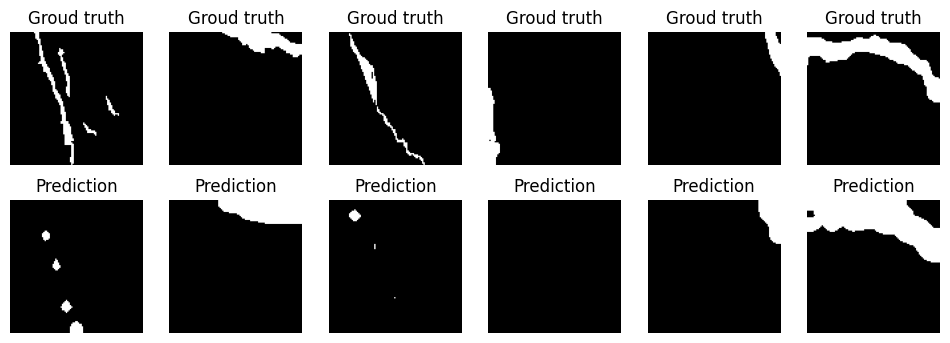

In [ ]:
# plot some examples of obtained segmentations
rows = 1
cols = 6

size_each = 2
fig, axes = plt.subplots(rows*2, cols,figsize =(cols*size_each, rows*2*size_each) )

for ax in axes.reshape(-1):
  ax.axis('off')

counter = random.randint(0, len(test_dataset) - cols*rows)
for r in range(rows):
  for c in range(cols):
    sample, mask = test_dataset[counter]
    counter += 1

        # do inference
    model.eval()
    with torch.no_grad():
      
      y_pred = model(sample.unsqueeze(0).to(device))
      y_pred = y_pred['out']

      pred = y_pred.argmax(1)

    axes[r*2][c].imshow(mask, cmap = 'gray')
    axes[r*2][c].title.set_text('Groud truth')
    
    axes[r*2+1][c].imshow(pred[0,...].to('cpu'), cmap = 'gray')
    axes[r*2+1][c].title.set_text('Prediction')

Compare the performance of both models.

Pre-trained network with Binary Cross Entropy Loss (Sigomid activation):
*   Pixel accuracy: 0.95
*   IoU score: 0.32


Pre-trained network with DiCe Loss (Softmax activation):
*   Pixel accuracy: 0.96
*   IoU score: 0.33

The performance in both models has similar results, probably, it would need more training and increase the sample for training either by adding new images or with data augmentation.